In [2]:
# %cd /home/maia-user/NeuroCBIR/
%cd /mnt/alvis2/user/NeuroCBIR

/mnt/alvis2/user/NeuroCBIR


**FIGURE: EXAMPLE OF RESULT - GT FOR WHOLE BRAIN**

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
seed = 1234

### Input data
# Path to dataset
DATA_PATH = "/mnt/kth_cbh/fenda/Datasets" # "/home/maia-user/cifs/Datasets/"


In [4]:
# # Load metadata
# import pandas as pd
# import os

# # Your existing list of DataFrames
# clinical_ds = [
#     pd.read_csv(os.path.join(DATA_PATH, "ADNI", "metadata.csv")),
#     pd.read_csv(os.path.join(DATA_PATH, "OASIS3", "metadata.csv")),
#     pd.read_csv(os.path.join(DATA_PATH, "AIBL", "metadata.csv")),
#     pd.read_csv(os.path.join(DATA_PATH, "SLIM", "metadata.csv")),
#     pd.read_csv(os.path.join(DATA_PATH, "MIRIAD", "metadata.csv"))
# ]

# # Combine into a single DataFrame
# clinical_ds = pd.concat(clinical_ds, axis=0, ignore_index=True)

# # (Optional) check shape and columns
# print(clinical_ds.shape)
# print(clinical_ds.columns)

In [5]:
# retrival_res = pd.read_csv("data/results/whole_brain/eval_cl16/retrieval.csv")
# retrival_res = retrival_res.rename(columns={"query": "GUID"})
# metadata = pd.merge(clinical_ds, retrival_res, on="GUID", how="inner") # Merge on the 'GUID' column
# print(f"METADATA: Original rows: {len(metadata)}")
# metadata.tail()

In [6]:
# metadata.query("project == 'oasis3'")


In [11]:
from dev.cbir.evaluation import retrieve_topk_for_queries
import pandas as pd
import os 
DATA_PATH = "/home/maia-user/cifs/Datasets/"

def load_metadata_whole_brain():
    # Constants
    
    embedding_file = "dev/data_private/results/whole_brain/eval__d_32__m_02__lid_02__mid_02__pn_005/projected_embeddings.parquet"
    metadata_path = "/mnt/alvis2/mimer_user/batched_datasets/combined_metadata.csv"
    
    # Load and filter metadata
    clinical_ds = pd.read_csv(metadata_path)

    # Load real features from parquet
    df_embs = pd.read_parquet(embedding_file)

    # Ensure GUID is string and joinable
    df_embs["GUID"] = df_embs["GUID"].astype(str)
    clinical_ds["GUID"] = clinical_ds["GUID"].astype(str)

    # Merge on GUID
    metadata = pd.merge(clinical_ds, df_embs, on="GUID", how="inner")
    
    # Apply filters to metadata
    metadata = metadata.query("repet == 1").reset_index(drop=True)
    metadata = metadata.query("useable == 1").reset_index(drop=True)
    metadata = metadata.query("mislabel == 0").reset_index(drop=True)
    metadata['subject'].replace('', pd.NA, inplace=True)
    metadata = metadata.dropna(subset=['subject']).reset_index(drop=True)
    metadata = metadata.dropna(subset=['partition']).reset_index(drop=True)

    # Convert embedding columns into a single 'features' column of vectors
    embedding_cols = [col for col in df_embs.columns if col != "GUID"]
    metadata["features"] = metadata[embedding_cols].apply(lambda row: row.to_numpy(), axis=1)
    return metadata

metadata = load_metadata_whole_brain()


/tmp/ipykernel_17100/4169704085.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata['subject'].replace('', pd.NA, inplace=True)


In [12]:
metadata.head()

,GUID,project,subject,timepoint,repet,scan_type,field_strength,manufacturer,model_name,disease,...,23,24,25,26,27,28,29,30,31,features
0,11c21c8b-e574-466a-9459-656e09277e24,adni,002_S_0295,m00,1,T1,1.5,NaN,NaN,CN,...,0.067916,0.152321,-0.371235,-0.094248,0.089141,-0.271892,0.409805,-0.084053,-0.093528,"[-0.4952973, -0.383988, 0.12389654, -0.2091352..."
1,4c6770b6-fe89-4f78-91ee-f0ede611bd90,adni,002_S_0295,m06,1,T1,1.5,GE MEDICAL SYSTEMS,SIGNA EXCITE,CN,...,0.054834,0.145864,-0.448967,-0.120157,0.028868,-0.293813,0.453430,-0.242631,-0.033918,"[-0.47957665, -0.3843863, 0.10680485, -0.21273..."
2,9dacc1e4-f52f-4b9e-9189-0db3c16b84a4,adni,002_S_0295,m12,1,T1,1.5,GE MEDICAL SYSTEMS,SIGNA EXCITE,CN,...,0.058575,0.131217,-0.393446,-0.117295,0.054223,-0.226874,0.459149,-0.188964,-0.075171,"[-0.4529847, -0.38238046, 0.13053109, -0.24471..."
3,283ba3d9-0278-4a64-98a8-5f5d2be8cd24,adni,002_S_0295,m24,1,T1,1.5,GE MEDICAL SYSTEMS,SIGNA EXCITE,CN,...,0.061529,0.140065,-0.370889,-0.065996,0.079835,-0.250684,0.464640,-0.185072,-0.023154,"[-0.46681154, -0.3924116, 0.10267308, -0.18719..."
4,ae9cdbab-6e48-4cf2-9062-91560cdfa7e4,adni,002_S_0295,m36,1,T1,1.5,GE MEDICAL SYSTEMS,SIGNA EXCITE,CN,...,0.062262,0.112710,-0.404154,-0.102199,0.087342,-0.274722,0.440087,-0.165673,-0.071846,"[-0.468373, -0.38365638, 0.118167505, -0.23599..."


In [ ]:
queries = metadata.query("project == 'oasis3'").sample(n=3, random_state=seed)
retrieval_df = retrieve_topk_for_queries(dataset, queries, top_k=top_k)

(A) Query: OAS31470_MR_d0007 from subject OAS31470 with a total of 1.
Other scans:
(B) I445714 - aibl
(C) I445696 - aibl
(D) OAS30927_MR_d1180 - oasis3
(E) OAS30616_MR_d0199 - oasis3
(F) I453074 - aibl


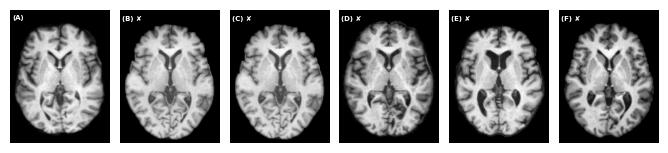

In [9]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

def crop_mri(image, target_shape=(160, 176, 208)):
    start = [48, 38, 10]
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata())

def plot_brain_slices(brains, titles, slice_index=None, axes=None, top_pad=7):
    """Plot middle slice (or given slice) of each brain in a row with top padding."""
    
    for i, (brain, title) in enumerate(zip(brains, titles)):
        # pick middle slice if not given
        idx = slice_index or brain.shape[1] // 2  
        slice_img = brain[:, idx, : ].T

        # add top padding (rows of zeros)
        slice_img_padded = np.pad(slice_img, ((0, top_pad), (0, 0)), mode='constant', constant_values=0)

        axes[i].imshow(slice_img_padded, cmap="gray", origin="lower")
        axes[i].axis("off")

        axes[i].text(
            0.02, 0.96, 
            title,
            horizontalalignment='left', 
            verticalalignment='top', 
            transform=axes[i].transAxes,
            color='w', fontsize=5, fontweight="bold"
        )


        
# figure
cm = 1/2.54 
fig, axes = plt.subplots(1, 6, figsize=(17*cm, 5*cm))

# Example usage:
query_guid = "OAS31470_MR_d0007"  # pick one from your metadata
row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
query_subject = row["subject"]  # store once outside loop

# Load query + top1–5
paths = [row["brain"]]
titles = ["(A)"]


title_caps = ["(B)", "(C)", "(D)", "(E)", "(F)"]
for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
    paths.append(match_row["brain"])
    titles.append(f"{title_caps[i]} {"✔" if match_row["subject"] == query_subject else "✘"}")

# Load brain volumes
brains = [load_nifti(p, DATA_PATH) for p in paths]

# Plot mid-slices
plot_brain_slices(brains, titles, axes=axes)

# Caption
n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
print(f"(A) Query: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
print("Other scans:")
for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
    print(f"{t_cap} {guid} - {project}")

plt.tight_layout()
plt.show()




(A.1): OAS30001_MR_d0129 from subject OAS30001 with a total of 6.
Other scans:
(A.2) OAS30001_MR_d0757 - oasis3
(A.3) OAS30001_MR_d2430 - oasis3
(A.4) OAS30001_MR_d3132 - oasis3
(A.5) OAS30001_MR_d3746 - oasis3
(A.6) OAS30001_MR_d4467 - oasis3
(B.1): OAS30052_MR_d1296 from subject OAS30052 with a total of 5.
Other scans:
(B.2) OAS30052_MR_d0693 - oasis3
(B.3) OAS30052_MR_d2737 - oasis3
(B.4) OAS30052_MR_d2709 - oasis3
(B.5) OAS30052_MR_d4235 - oasis3
(B.6) OAS31193_MR_d0275 - oasis3
(C.1): OAS31470_MR_d0007 from subject OAS31470 with a total of 1.
Other scans:
(C.2) I445714 - aibl
(C.3) I445696 - aibl
(C.4) OAS30927_MR_d1180 - oasis3
(C.5) OAS30616_MR_d0199 - oasis3
(C.6) I453074 - aibl


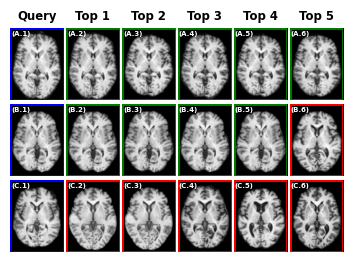

In [ ]:
import matplotlib.patches as patches

queries_guid = ["OAS30001_MR_d0129", "OAS30052_MR_d1296", "OAS31470_MR_d0007"]
title_capss = [["(A.1)", "(A.2)", "(A.3)", "(A.4)", "(A.5)", "(A.6)"],
               ["(B.1)", "(B.2)", "(B.3)", "(B.4)", "(B.5)", "(B.6)"],
               ["(C.1)", "(C.2)", "(C.3)", "(C.4)", "(C.5)", "(C.6)"]]

# figure
cm = 1/2.54 
n_queries = len(queries_guid)
fig, axess = plt.subplots(n_queries, 6, figsize=(9*cm, 6.7*cm))#, figsize=(18*cm, n_queries*4.1*cm))

for axes, query_guid, title_caps in zip(axess, queries_guid, title_capss):
# axes = axess[0]

    # Example usage:
    row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
    query_subject = row["subject"]  # store once outside loop

    # Load query + top1–5
    paths = [row["brain"]]
    titles = [title_caps[0]]
    labels = []  # will store hit/fail info

    title_caps = title_caps[1:]
    for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
        paths.append(match_row["brain"])
        is_hit = match_row["subject"] == query_subject
        labels.append(is_hit)
        # titles.append(f"{title_caps[i]} {'✔' if is_hit else '✘'}")
        titles.append(f"{title_caps[i]}")

    # Load brain volumes
    brains = [load_nifti(p, DATA_PATH) for p in paths]

    # Plot mid-slices
    plot_brain_slices(brains, titles, axes=axes)
    
    # --- Add borders ---
    for j, ax in enumerate(axes):
        # query
        if j == 0:
            color = "blue"
        else:
            color = "green" if labels[j-1] else "red"

        rect = patches.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            linewidth=2.0,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

    # Caption
    n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
    print(f"{titles[0]}: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
    print("Other scans:")
    for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
        print(f"{t_cap} {guid} - {project}")

axess[0][0].set_title("Query", fontweight="bold")
axess[0][1].set_title("Top 1", fontweight="bold")
axess[0][2].set_title("Top 2", fontweight="bold")
axess[0][3].set_title("Top 3", fontweight="bold")
axess[0][4].set_title("Top 4", fontweight="bold")
axess[0][5].set_title("Top 5", fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(wspace=+0.04, hspace=0)

# plt.savefig(f"figures/example_brain_retrieval.pdf", format='pdf', 
# dpi=600,  # increase for higher-resolution embedded images
# bbox_inches='tight', pad_inches=0)
plt.show()

In [8]:
halt

NameError: name 'halt' is not defined

**FIGURE: EXAMPLE OF RESULT - GT FOR BRAIN REGION**

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

### Input data
# Path to dataset
DATA_PATH = "/home/maia-user/cifs/Datasets/"


In [ ]:
# Load metadata
import pandas as pd
import os

# Your existing list of DataFrames
clinical_ds = [
    pd.read_csv(os.path.join(DATA_PATH, "ADNI", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "OASIS3", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "AIBL", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "SLIM", "metadata.csv")),
    pd.read_csv(os.path.join(DATA_PATH, "MIRIAD", "metadata.csv"))
]

# Combine into a single DataFrame
clinical_ds = pd.concat(clinical_ds, axis=0, ignore_index=True)

# (Optional) check shape and columns
print(clinical_ds.shape)
print(clinical_ds.columns)

(26693, 15)
Index(['GUID', 'project', 'subject', 'timepoint', 'scan_type',
       'field_strength', 'manufacturer', 'model_name', 'disease', 'age',
       'brain', 'sex', 'acq_date', 'raw', 'seg'],
      dtype='object')


In [ ]:
retrival_res = pd.read_csv("data/results/region_brain/eval_cl32/retrieval_all.csv")
retrival_res = retrival_res.rename(columns={"query": "GUID"})
metadata = pd.merge(clinical_ds, retrival_res, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")
struct_name = "Right-Hippocampus"
metadata = metadata.query(f"LabelName == '{struct_name}'")
print(f"METADATA: after filering rows: {len(metadata)}")


METADATA: Original rows: 2857351
METADATA: after filering rows: 26176


In [ ]:
metadata.query("project == 'oasis3'")

,GUID,project,subject,timepoint,scan_type,field_strength,manufacturer,model_name,disease,age,...,sex,acq_date,raw,seg,top1,top2,top3,top4,top5,LabelName
2268107,OAS30001_MR_d0129,oasis3,OAS30001,129,T1,3.0,SIEMENS,TrioTim,CN,65.5,...,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d0129/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d0129/mri/align_apar...,OAS30001_MR_d0757,OAS30001_MR_d4467,OAS30001_MR_d3132,OAS30001_MR_d2430,OAS30001_MR_d3746,Right-Hippocampus
2268219,OAS30001_MR_d0757,oasis3,OAS30001,757,T1,3.0,SIEMENS,TrioTim,CN,67.3,...,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d0757/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d0757/mri/align_apar...,OAS30001_MR_d4467,OAS30001_MR_d3132,OAS30001_MR_d0129,OAS30001_MR_d2430,OAS30001_MR_d3746,Right-Hippocampus
2268331,OAS30001_MR_d2430,oasis3,OAS30001,2430,T1,3.0,SIEMENS,Biograph_mMR,CN,71.8,...,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d2430/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d2430/mri/align_apar...,OAS30001_MR_d3746,OAS30001_MR_d4467,OAS30001_MR_d0757,OAS30001_MR_d3132,OAS30001_MR_d0129,Right-Hippocampus
2268443,OAS30001_MR_d3132,oasis3,OAS30001,3132,T1,3.0,SIEMENS,TrioTim,CN,73.8,...,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d3132/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d3132/mri/align_apar...,OAS30001_MR_d0757,OAS30001_MR_d4467,OAS30001_MR_d3746,OAS30001_MR_d0129,OAS30001_MR_d2430,Right-Hippocampus
2268555,OAS30001_MR_d3746,oasis3,OAS30001,3746,T1,3.0,SIEMENS,Biograph_mMR,CN,75.5,...,NaN,NaN,OASIS3/oasis3/OAS30001_MR_d3746/mri/orig/001.mgz,OASIS3/oasis3/OAS30001_MR_d3746/mri/align_apar...,OAS30001_MR_d2430,OAS30001_MR_d3132,OAS30001_MR_d4467,OAS30001_MR_d0757,OAS30001_MR_d0129,Right-Hippocampus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2568667,OAS31470_MR_d0007,oasis3,OAS31470,7,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,64.9,...,NaN,NaN,OASIS3/oasis3/OAS31470_MR_d0007/mri/orig/001.mgz,OASIS3/oasis3/OAS31470_MR_d0007/mri/align_apar...,slim_25762_2,slim_25794_1,slim_30980_1,slim_30883_1,slim_30828_1,Right-Hippocampus
2568779,OAS31471_MR_d0059,oasis3,OAS31471,59,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,65.5,...,NaN,NaN,OASIS3/oasis3/OAS31471_MR_d0059/mri/orig/001.mgz,OASIS3/oasis3/OAS31471_MR_d0059/mri/align_apar...,2a24aaca-69ae-4dbc-9591-1eb6c7c531d9,610f4df2-e22f-4b2a-9849-5e466bdcc424,I472743,9a356541-1b93-49d2-9c1d-55fcf2ddd904,OAS31323_MR_d0123,Right-Hippocampus
2568892,OAS31472_MR_d0045,oasis3,OAS31472,45,T1,3.0,SIEMENS,MAGNETOM_Vida,CN,67.4,...,NaN,NaN,OASIS3/oasis3/OAS31472_MR_d0045/mri/orig/001.mgz,OASIS3/oasis3/OAS31472_MR_d0045/mri/align_apar...,slim_30753_3,slim_30753_1,OAS31016_MR_d0126,03195db1-70ec-4556-90d2-1477d7f7b764,0b5b00cd-4698-4670-90c9-7f79900aae40,Right-Hippocampus
2569005,OAS31473_MR_d0136,oasis3,OAS31473,136,T1,3.0,SIEMENS,Biograph_mMR,CN,57.0,...,NaN,NaN,OASIS3/oasis3/OAS31473_MR_d0136/mri/orig/001.mgz,OASIS3/oasis3/OAS31473_MR_d0136/mri/align_apar...,OAS30595_MR_d0848,OAS30595_MR_d0084,OAS31311_MR_d0055,558d6564-0369-4450-9d7e-96dfd19b6640,3a1cb653-0fa4-42c0-916b-92d06a435190,Right-Hippocampus


In [ ]:
# Load labels and bounding boxes for cortical/subcortical structures
labels_df = pd.read_csv("data/labels.csv")
bb_df = pd.read_csv("data/bounding_boxes.csv")
labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column

(A) Query: OAS30001_MR_d0129 from subject OAS30001 with a total of 6.
Other scans:
(B) OAS30001_MR_d0757 - oasis3
(C) OAS30001_MR_d4467 - oasis3
(D) OAS30001_MR_d3132 - oasis3
(E) OAS30001_MR_d2430 - oasis3
(F) OAS30001_MR_d3746 - oasis3


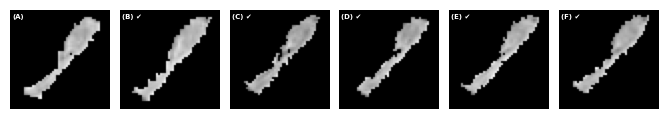

In [ ]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

def crop_mri(image, target_shape=(160, 176, 208)):
    start = [48, 38, 10]
    end = np.minimum(np.array(start) + np.array(target_shape), image.shape)
    cropped = image[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
    return cropped

def load_nifti(path, data_path):
    """Load a nii.gz or mgz file given a relative path from metadata."""
    full_path = os.path.join(data_path, path)
    img = nib.load(full_path)
    return crop_mri(img.get_fdata())

def plot_struct_slices(brains, titles, slice_index=None, axes=None):
    """Plot middle slice (or given slice) of each brain in a row."""
    
    for i, (brain, title) in enumerate(zip(brains, titles)):
        # pick middle slice if not given
        idx = slice_index or brain.shape[0] // 2  
        axes[i].imshow(brain[idx, :, : ].T, cmap="gray", origin="lower")
        # axes[i].set_title(title, y=0.9, x=0.35, va="top", color='w') #, fontsize=8)
        axes[i].axis("off")
        axes[i].text(0.02, 0.96, title, horizontalalignment='left', 
                     verticalalignment='top', transform=axes[i].transAxes, color='w', fontsize=5, fontweight="bold")
        
def obtain_struct(brain_path, seg_path, DATA_PATH, target_struct_name, labels_bb_df):
    image = load_nifti(brain_path, DATA_PATH).astype(np.float32)
    seg = load_nifti(seg_path, DATA_PATH)

    # Filter the label row for the selected structure
    struct_row_df = labels_bb_df.query(f"LabelName == '{target_struct_name}' and Use == 1").reset_index(drop=True)
    if len(struct_row_df) == 0:
        raise ValueError(f"Structure '{target_struct_name}' not found in labels_bb_df with Use == 1.")
    struct_row = struct_row_df.iloc[0]
    struct_map_id = struct_row["LabelID"]

    # Bounding box
    x1, x2 = int(struct_row["min_x"]) - 5, int(struct_row["max_x"]) + 5
    y1, y2 = int(struct_row["min_y"]) - 5, int(struct_row["max_y"]) + 5
    z1, z2 = int(struct_row["min_z"]) - 5, int(struct_row["max_z"]) + 5

    # Preprocess all samples
    patch_brain = image[x1:x2, y1:y2, z1:z2]
    patch_seg = (seg[x1:x2, y1:y2, z1:z2] == struct_map_id)

    struct = patch_brain * patch_seg
    
    return struct

        
# figure
cm = 1/2.54 
fig, axes = plt.subplots(1, 6, figsize=(17*cm, 5*cm))

# Example usage:
query_guid = "OAS30001_MR_d0129"  # pick one from your metadata
row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
query_subject = row["subject"]  # store once outside loop

# Load query + top1–5
paths = [[row["brain"], row["seg"]]]
titles = ["(A)"]

title_caps = ["(B)", "(C)", "(D)", "(E)", "(F)"]
for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
    paths.append([match_row["brain"], match_row["seg"]])
    titles.append(f"{title_caps[i]} {"✔" if match_row["subject"] == query_subject else "✘"}")

# Load brain volumes
structs = [obtain_struct(brain_path, seg_path, DATA_PATH, struct_name, labels_bb_df) for brain_path, seg_path in paths]

# Plot mid-slices
plot_struct_slices(structs, titles, axes=axes)

# Caption
n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
print(f"(A) Query: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
print("Other scans:")
for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
    guid = row[col]
    project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
    print(f"{t_cap} {guid} - {project}")

plt.tight_layout()
plt.show()

(A.1): OAS30001_MR_d0129 from subject OAS30001 with a total of 6.
Other scans:
(A.2) OAS30001_MR_d0757 - oasis3
(A.3) OAS30001_MR_d4467 - oasis3
(A.4) OAS30001_MR_d3132 - oasis3
(A.5) OAS30001_MR_d2430 - oasis3
(A.6) OAS30001_MR_d3746 - oasis3
(B.1): OAS30052_MR_d1296 from subject OAS30052 with a total of 5.
Other scans:
(B.2) OAS30052_MR_d2709 - oasis3
(B.3) OAS30052_MR_d2737 - oasis3
(B.4) OAS30052_MR_d0693 - oasis3
(B.5) OAS30052_MR_d4235 - oasis3
(B.6) OAS30284_MR_d1633 - oasis3
(C.1): OAS31470_MR_d0007 from subject OAS31470 with a total of 1.
Other scans:
(C.2) slim_25762_2 - slim
(C.3) slim_25794_1 - slim
(C.4) slim_30980_1 - slim
(C.5) slim_30883_1 - slim
(C.6) slim_30828_1 - slim


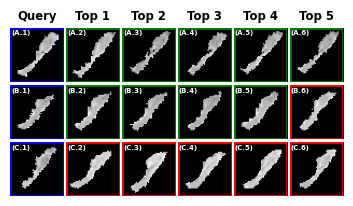

In [ ]:
import matplotlib.patches as patches

queries_guid = ["OAS30001_MR_d0129", "OAS30052_MR_d1296", "OAS31470_MR_d0007"]
title_capss = [["(A.1)", "(A.2)", "(A.3)", "(A.4)", "(A.5)", "(A.6)"],
               ["(B.1)", "(B.2)", "(B.3)", "(B.4)", "(B.5)", "(B.6)"],
               ["(C.1)", "(C.2)", "(C.3)", "(C.4)", "(C.5)", "(C.6)"]]

# figure
cm = 1/2.54 
n_queries = len(queries_guid)
fig, axess = plt.subplots(n_queries, 6, figsize=(9*cm, 5.25*cm))#, figsize=(18*cm, n_queries*4.1*cm))

for axes, query_guid, title_caps in zip(axess, queries_guid, title_capss):
# axes = axess[0]

    # Example usage:
    row = metadata.loc[metadata["GUID"] == query_guid].iloc[0]
    query_subject = row["subject"]  # store once outside loop

    # Load query + top1–5
    paths = [[row["brain"], row["seg"]]]
    titles = [title_caps[0]]
    labels=[]

    title_caps = title_caps[1:]
    for i, col in enumerate(["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        match_row = metadata.loc[metadata["GUID"] == guid].iloc[0]
        paths.append([match_row["brain"], match_row["seg"]])
        is_hit = match_row["subject"] == query_subject
        labels.append(is_hit)
        # titles.append(f"{title_caps[i]} {'✔' if is_hit else '✘'}")
        titles.append(f"{title_caps[i]}")

    # Load brain volumes
    structs = [obtain_struct(brain_path, seg_path, DATA_PATH, struct_name, labels_bb_df) for brain_path, seg_path in paths]

    # Plot mid-slices
    plot_struct_slices(structs, titles, axes=axes)
    
    # --- Add borders ---
    for j, ax in enumerate(axes):
        # query
        if j == 0:
            color = "blue"
        else:
            color = "green" if labels[j-1] else "red"

        rect = patches.Rectangle(
            (0, 0), 1, 1,
            transform=ax.transAxes,
            linewidth=2.0,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

    # Caption
    n_scan_subject = metadata.query(f"subject == '{query_subject}'").shape[0]
    print(f"{titles[0]}: {query_guid} from subject {query_subject} with a total of {n_scan_subject}.")
    print("Other scans:")
    for t_cap, col in zip(title_caps, ["top1", "top2", "top3", "top4", "top5"]):
        guid = row[col]
        project = metadata.loc[metadata["GUID"] == guid]["project"].iloc[0]
        print(f"{t_cap} {guid} - {project}")

axess[0][0].set_title("Query", fontweight="bold")
axess[0][1].set_title("Top 1", fontweight="bold")
axess[0][2].set_title("Top 2", fontweight="bold")
axess[0][3].set_title("Top 3", fontweight="bold")
axess[0][4].set_title("Top 4", fontweight="bold")
axess[0][5].set_title("Top 5", fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(wspace=0.04, hspace=0)

plt.savefig(f"figures/example_struct_retrieval.pdf", format='pdf', 
dpi=600,  # increase for higher-resolution embedded images
bbox_inches='tight', pad_inches=0)
plt.show()

# plt.savefig(f"figures/example_struct_retrieval.pdf", format='pdf', bbox_inches='tight')
# plt.show()